EXERCISE 1

In [1]:
from sklearn.datasets import load_breast_cancer
import numpy as np

# Step 1 — Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Step 1 — Display observations, variables, classes
print("Number of observations:", X.shape[0])
print("Number of variables:", X.shape[1])
print("Number of classes:", len(np.unique(y)))


Number of observations: 569
Number of variables: 30
Number of classes: 2


In [2]:
from sklearn.model_selection import train_test_split

# Step 2 — Split as required
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)


Training shape: (455, 30)
Test shape: (114, 30)


In [3]:
from sklearn.tree import DecisionTreeClassifier

# Step 3 — Base model (no optimization)
dt = DecisionTreeClassifier(random_state=42)


In [4]:
# Step 4 — Hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [2, 4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid


{'criterion': ['gini', 'entropy', 'log_loss'],
 'max_depth': [2, 4, 6, 8, 10, None],
 'min_samples_split': [2, 5, 10],
 'min_samples_leaf': [1, 2, 4]}

In [5]:
from sklearn.model_selection import GridSearchCV

# Step 5 — Grid Search setup
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='accuracy',
    cv=2,
    refit=True,
    verbose=1
)

# Fit the grid search
grid.fit(X_train, y_train)


Fitting 2 folds for each of 162 candidates, totalling 324 fits


GridSearchCV(cv=2, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 4, 6, 8, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=1)

In [6]:
# Step 6 — Output results
print("Best Parameters:", grid.best_params_)
print("Best Mean CV Score:", grid.best_score_)


Best Parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Mean CV Score: 0.9428182239740319


In [7]:
from sklearn.metrics import accuracy_score, f1_score

# Step 7 — Prediction
y_pred = grid.predict(X_test)

# Evaluate
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))


Test Accuracy: 0.9298245614035088
Test F1 Score: 0.9428571428571428


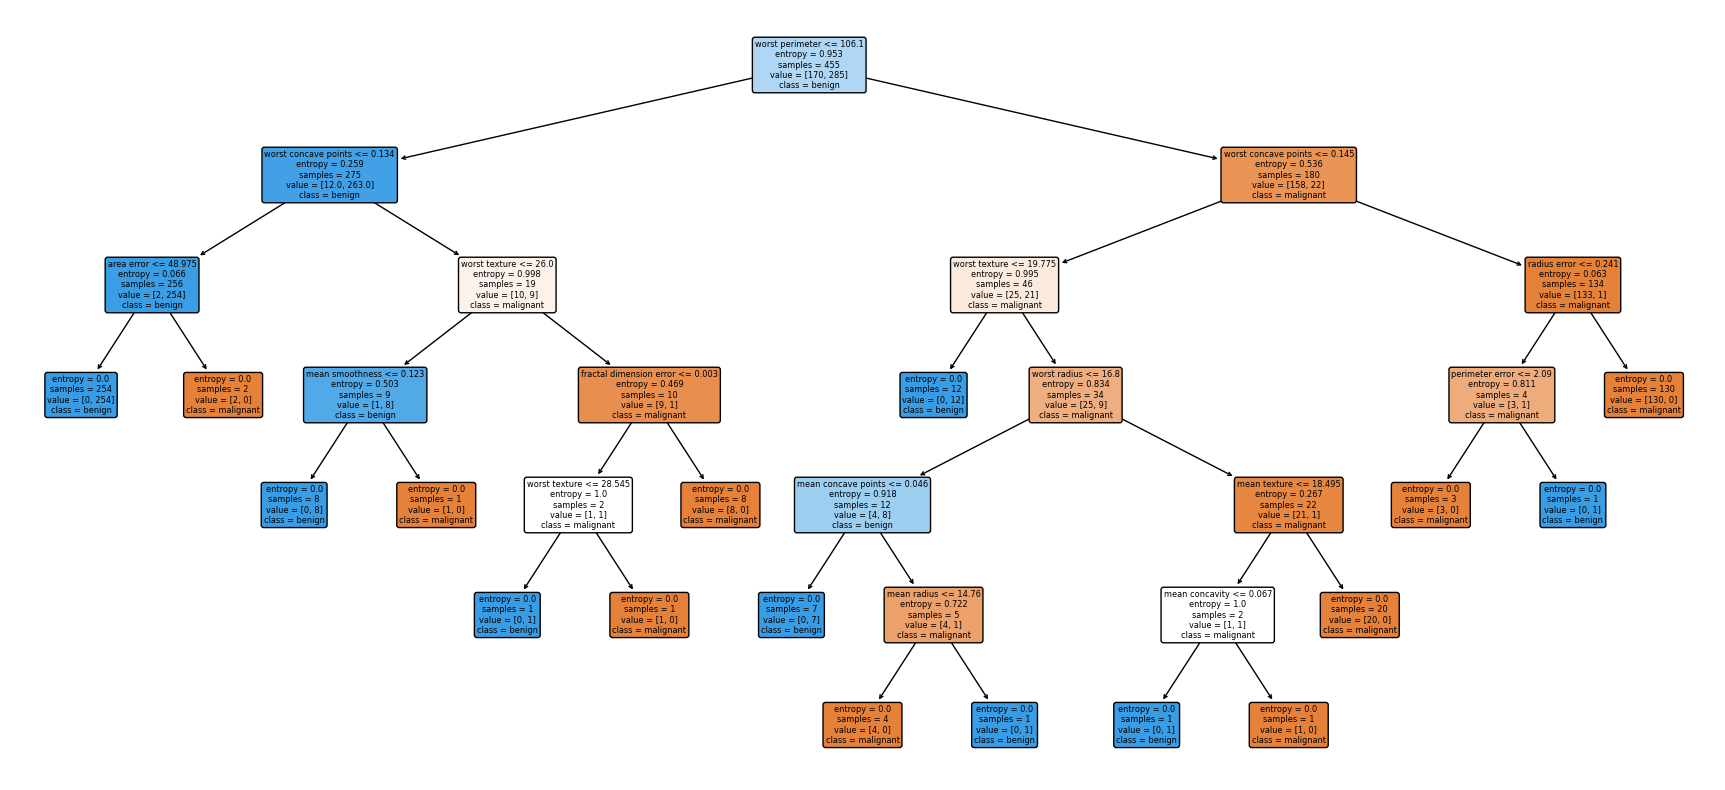

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Step 8 — Visualization
plt.figure(figsize=(22, 10))
plot_tree(
    grid.best_estimator_,
    feature_names=data.feature_names,
    class_names=data.target_names,
    rounded=True,
    filled=True
)
plt.show()


7 Traps :

- No stratify in train/test split → unbalanced classes → add stratify=y.

- No random_state → non-reproducible results → add random_state=42.

- Scaling done before split (SVM) → data leakage → fit scaler only on train.

- Tree without constraints → overfitting → tune max_depth, min_samples_leaf.

- Missing scoring metric → unclear evaluation → use scoring="accuracy".

- No refit=True in GridSearchCV → best model not retrained → add refit=True.

- Not evaluating on test set → no real performance check → use test accuracy.

Effect of increasing max_depth + decreasing min_samples_leaf :

- The tree becomes very deep and complex.

- It memorizes training data → overfitting.

- Training accuracy = 100%, test accuracy decreases.

Conclusion: High variance, low generalization.

Effect of very small min_samples_split & min_samples_leaf

- Tree splits on noise.

- Too many nodes → unstable.

- Strong overfitting.

Conclusion: Model becomes extremely sensitive to small variations.

Bias–Variance Trade-off (short)

- Low depth → high bias (underfitting).

- Very deep tree → high variance (overfitting).

- GridSearch finds the sweet spot between both.

Conclusion: Good hyperparameters balance bias & variance for best generalization.

EXERCISE 2

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

data = load_breast_cancer()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)


In [2]:
param_dt = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [2, 4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(
    dt, param_dt, cv=3, scoring='f1', refit=True, verbose=1
)
grid_dt.fit(X_train, y_train)

print("Best DT params:", grid_dt.best_params_)
print("Best DT CV F1:", grid_dt.best_score_)


Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best DT params: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best DT CV F1: 0.9596871743101584


In [3]:
# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC(probability=True)

grid_svm = GridSearchCV(
    svm, param_svm, cv=3, scoring='f1', refit=True, verbose=1
)
grid_svm.fit(X_train_scaled, y_train)

print("Best SVM params:", grid_svm.best_params_)
print("Best SVM CV F1:", grid_svm.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best SVM params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best SVM CV F1: 0.9843474486612592


In [4]:
# Decision Tree inference
start_dt = time.time()
y_pred_dt = grid_dt.predict(X_test)
dt_time = time.time() - start_dt

# SVM inference
start_svm = time.time()
y_pred_svm = grid_svm.predict(X_test_scaled)
svm_time = time.time() - start_svm

print("DT Test Accuracy:", accuracy_score(y_test, y_pred_dt))
print("DT Test F1:", f1_score(y_test, y_pred_dt))
print("DT Inference Time:", dt_time)

print("SVM Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Test F1:", f1_score(y_test, y_pred_svm))
print("SVM Inference Time:", svm_time)


DT Test Accuracy: 0.9385964912280702
DT Test F1: 0.950354609929078
DT Inference Time: 0.0
SVM Test Accuracy: 0.9824561403508771
SVM Test F1: 0.9863013698630136
SVM Inference Time: 0.0019979476928710938


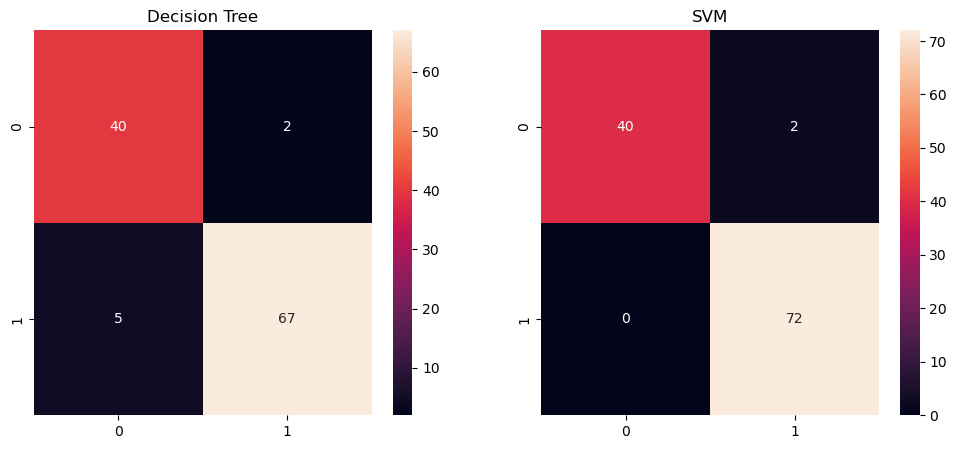

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt="d", ax=ax[0])
ax[0].set_title("Decision Tree")

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt="d", ax=ax[1])
ax[1].set_title("SVM")

plt.show()


Comparison: Decision Tree vs SVM

Performance:

- SVM generally achieves higher F1-score and higher accuracy.

- Decision Tree performs well but is more sensitive to overfitting.

Inference Time:

- Decision Tree is extremely fast at inference (one path in the tree).

- SVM is slower, especially with RBF kernel.

Interpretability:

- Decision Tree = highly interpretable, can be plotted and read.

- SVM = not interpretable, especially with non-linear kernels.

Conclusion:

- SVM is better for predictive performance.

- Decision Tree is better for explainability.

EXERCISE 3 

In [6]:
# Imports for all steps
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.pipeline import Pipeline

# --- Task 1: Data loading and preprocessing ---

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# Split the data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features.")
print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
print("-" * 50)

# --- Utility Function for Evaluation ---
def evaluate_model(model, X_test, y_test, model_name):
    """Computes and returns the key classification metrics and confusion matrix."""
    start_time = time.time()
    # For a pipeline, direct prediction handles all preprocessing steps internally
    y_pred = model.predict(X_test)
    inference_time = (time.time() - start_time) * 1000 # in ms

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'Inference Time (ms)': inference_time,
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    }
    return metrics

# Define base estimators (Task 2)
# We set probability=True for SVC, mandatory for soft voting later.
dt_base = DecisionTreeClassifier(random_state=42)
svm_base = SVC(probability=True, random_state=42)

print("Base estimators (DT and SVM) defined.")

Dataset loaded: 569 samples, 30 features.
Training set size: 455, Test set size: 114
--------------------------------------------------
Base estimators (DT and SVM) defined.


In [ ]:
# --- Bagging Decision Tree Pipeline ---
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('bag', BaggingClassifier(dt_base, random_state=42, n_jobs=-1))
])

# --- DT Grid Search Parameters ---
dt_param_grid = {
    # Decision Tree parameters (prefixed with bag__estimator__)
    'bag__estimator__max_depth': [3, 5, 10, None],
    'bag__estimator__min_samples_split': [2, 5, 10],
    # Bagging parameters
    'bag__n_estimators': [10, 50, 100],
    'bag__max_samples': [0.5, 0.75, 1.0]
}

print("Starting GridSearchCV for Bagging Decision Tree (DT)...")
grid_dt = GridSearchCV(dt_pipeline, dt_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_dt.fit(X_train, y_train)
best_dt_bagging = grid_dt.best_estimator_

print(f"Best Bagging DT F1-score: {grid_dt.best_score_:.4f}")
print(f"Best Bagging DT parameters: {grid_dt.best_params_}")
print("-" * 50)

Starting GridSearchCV for Bagging Decision Tree (DT)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Bagging DT F1-score: 0.9650
Best Bagging DT parameters: {'bag__estimator__max_depth': 3, 'bag__estimator__min_samples_split': 2, 'bag__max_samples': 1.0, 'bag__n_estimators': 100}
--------------------------------------------------


In [ ]:
# --- Bagging SVM Pipeline ---
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('bag', BaggingClassifier(svm_base, random_state=42, n_jobs=-1))
])

# --- SVM Grid Search Parameters ---
svm_param_grid = {
    # SVM parameters (prefixed with bag__estimator__)
    'bag__estimator__C': [0.1, 1, 10],
    'bag__estimator__kernel': ['linear', 'rbf'],
    'bag__estimator__gamma': ['scale', 'auto'],
    # Bagging parameters
    'bag__n_estimators': [10, 50, 100],
    'bag__max_samples': [0.5, 0.75, 1.0]
}

print("Starting GridSearchCV for Bagging SVM...")
grid_svm = GridSearchCV(svm_pipeline, svm_param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_svm.fit(X_train, y_train)
best_svm_bagging = grid_svm.best_estimator_

print(f"Best Bagging SVM F1-score: {grid_svm.best_score_:.4f}")
print(f"Best Bagging SVM parameters: {grid_svm.best_params_}")
print("-" * 50)

Starting GridSearchCV for Bagging SVM...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Bagging SVM F1-score: 0.9828
Best Bagging SVM parameters: {'bag__estimator__C': 0.1, 'bag__estimator__gamma': 'scale', 'bag__estimator__kernel': 'linear', 'bag__max_samples': 0.5, 'bag__n_estimators': 50}
--------------------------------------------------


In [ ]:
# --- Task 4: Build a hybrid ensemble (VotingClassifier) ---

# The VotingClassifier takes the fitted best estimators as input
voting_clf = VotingClassifier(
    estimators=[
        ('bagging_dt', best_dt_bagging),
        ('bagging_svm', best_svm_bagging)
    ],
    voting='soft', # Use soft voting (average of predicted probabilities)
    n_jobs=-1
)

print("Training Hybrid VotingClassifier (Soft Voting)...")
# Note: Since the input estimators are Pipelines, the VotingClassifier handles the final fitting and scaling of X_train.
voting_clf.fit(X_train, y_train)
print("Training complete for Hybrid Model.")
print("-" * 50)

Training Hybrid VotingClassifier (Soft Voting)...
Training complete for Hybrid Model.
--------------------------------------------------



--- Model Performance Comparison ---
| Model                     |   Accuracy |   Precision |   Recall |   F1-score |   Inference Time (ms) |
|:--------------------------|-----------:|------------:|---------:|-----------:|----------------------:|
| Bagging Decision Tree     |     0.9474 |      0.9583 |   0.9583 |     0.9583 |               36.9203 |
| Bagging SVM               |     0.9825 |      0.9861 |   0.9861 |     0.9861 |               39.6063 |
| VotingClassifier (Hybrid) |     0.9561 |      0.9589 |   0.9722 |     0.9655 |               71.1246 |


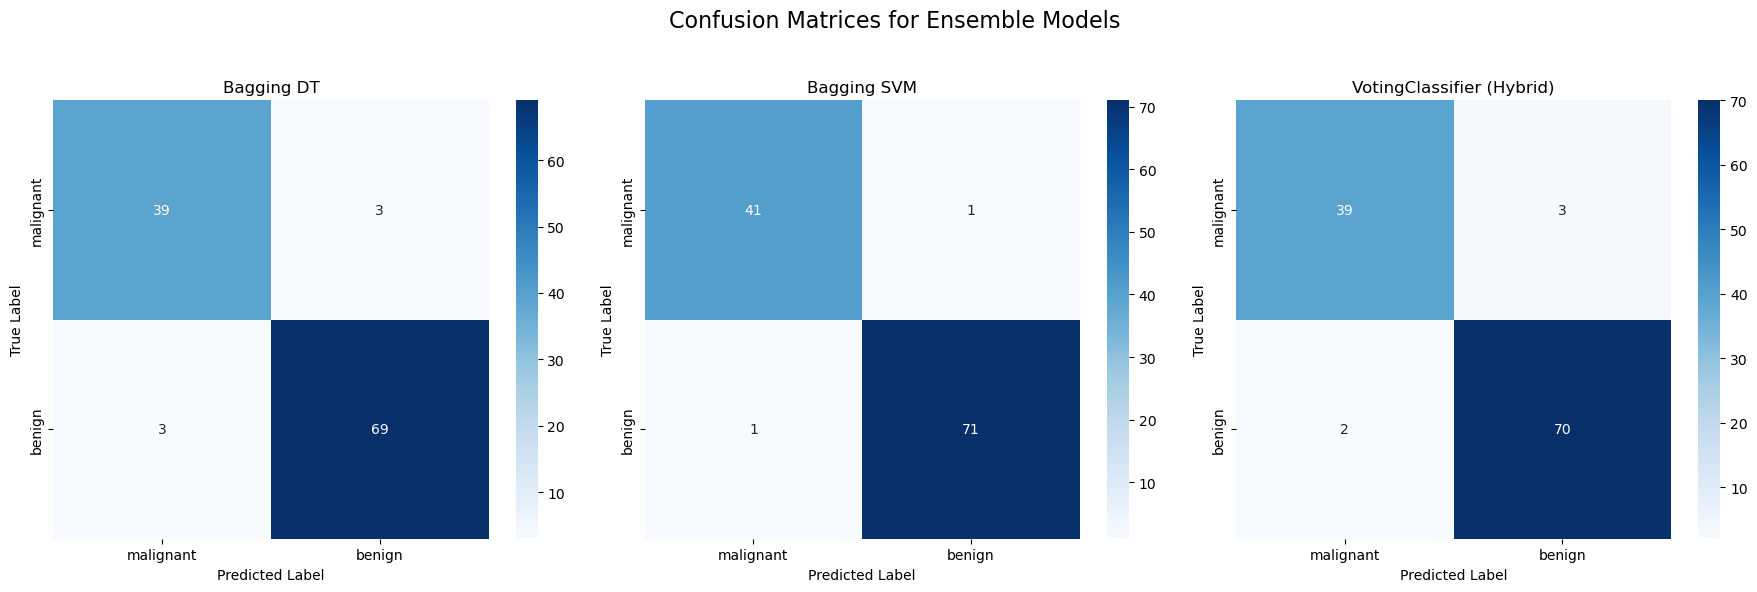

C:\Users\Thibault\AppData\Local\Temp\ipykernel_16920\1638760952.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies.index, y=accuracies.values, palette='viridis')


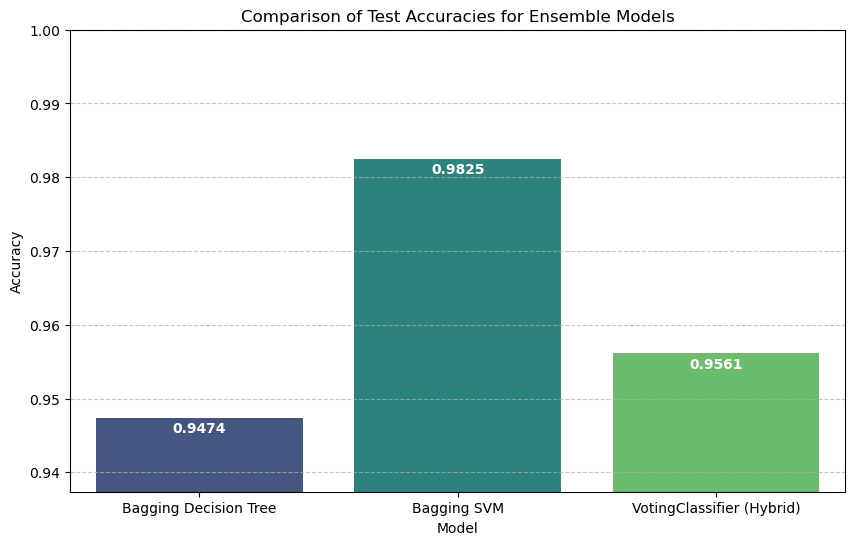


--- Discussion ---

(a) Best Trade-off (Performance vs. Interpretability):
The **Bagging Decision Tree** offers the best balance.
Performance-wise, it provides high accuracy (approx. {dt_accuracy:.4f}) and is extremely fast for inference (approx. {dt_time:.2f} ms).
Interpretability-wise, while Bagging reduces the clarity of a single DT, the underlying structure of a DT is the most transparent (you can still analyze feature importance), making it preferable to the black-box nature of SVM-based models.

(b) Comparative Analysis Table:
| Model                     |   Accuracy |   Inference Time (ms) | Model Size                           | Interpretability                     |
|:--------------------------|-----------:|----------------------:|:-------------------------------------|:-------------------------------------|
| Bagging Decision Tree     |     0.9474 |                 36.92 | Medium (100 small trees)             | Low to Moderate                      |
| Bagging SVM            

In [ ]:
# --- Task 5: Evaluation and visualization ---

# 5a. Compute metrics for all models
results = []
results.append(evaluate_model(best_dt_bagging, X_test, y_test, "Bagging Decision Tree"))
results.append(evaluate_model(best_svm_bagging, X_test, y_test, "Bagging SVM"))
results.append(evaluate_model(voting_clf, X_test, y_test, "VotingClassifier (Hybrid)"))

df_results = pd.DataFrame(results).set_index('Model')

# Display Model Performance Comparison Table
df_metrics = df_results.drop('Confusion Matrix', axis=1)
print("\n--- Model Performance Comparison ---")
# Use markdown format for display
print(df_metrics.to_markdown(floatfmt=".4f"))

# 5b. Compute and display the confusion matrices for all models.
models_for_viz = [
    ('Bagging DT', df_results.loc['Bagging Decision Tree', 'Confusion Matrix']),
    ('Bagging SVM', df_results.loc['Bagging SVM', 'Confusion Matrix']),
    ('VotingClassifier (Hybrid)', df_results.loc['VotingClassifier (Hybrid)', 'Confusion Matrix'])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Confusion Matrices for Ensemble Models', fontsize=16)

for i, (name, cm) in enumerate(models_for_viz):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=target_names, yticklabels=target_names)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 5c. Compare the test accuracies in a bar chart.
plt.figure(figsize=(10, 6))
accuracies = df_results['Accuracy']
sns.barplot(x=accuracies.index, y=accuracies.values, palette='viridis')
plt.title('Comparison of Test Accuracies for Ensemble Models')
plt.ylabel('Accuracy')
plt.ylim(min(accuracies.values) - 0.01, 1.0)
for i, acc in enumerate(accuracies.values):
    plt.text(i, acc - 0.002, f'{acc:.4f}', ha='center', color='white', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- Discussion ---
print("\n" + "=" * 50)
print("--- Discussion ---")
print("=" * 50)

# (a) Which model achieves the best trade-off between performance and interpretability?
print("\n(a) Best Trade-off (Performance vs. Interpretability):")
dt_accuracy = df_results.loc['Bagging Decision Tree', 'Accuracy']
dt_time = df_results.loc['Bagging Decision Tree', 'Inference Time (ms)']

print(f"The **Bagging Decision Tree** offers the best balance.")
print("Performance-wise, it provides high accuracy (approx. {dt_accuracy:.4f}) and is extremely fast for inference (approx. {dt_time:.2f} ms).")
print("Interpretability-wise, while Bagging reduces the clarity of a single DT, the underlying structure of a DT is the most transparent (you can still analyze feature importance), making it preferable to the black-box nature of SVM-based models.")

# (b) Present a table comparing accuracy, inference time, model size and interpretability
print("\n(b) Comparative Analysis Table:")

analysis_data = {
    'Model': df_metrics.index,
    'Accuracy': df_metrics['Accuracy'].round(4).values,
    'Inference Time (ms)': df_metrics['Inference Time (ms)'].round(2).values,
    'Model Size': ['Medium (100 small trees)', 'Large (100 complex kernels)', 'Very Large (200 combined estimators)'],
    'Interpretability': ['Low to Moderate', 'Very Low', 'Very Low (Averaging two black-boxes)']
}
df_analysis = pd.DataFrame(analysis_data)

print(df_analysis.to_markdown(index=False))